In [3]:
import datasets
ds = datasets.Dataset.from_json('ipo_final.json')
ds

Generating train split: 0 examples [00:00, ? examples/s]

Dataset({
    features: ['prompt', 'target', 'nums', 'ground_truth', 'response', 'scores'],
    num_rows: 50
})

In [4]:
import os
def map_fn(example):
    example['is_correct'] = [x==1.0 for x in example['scores']]
    return example

ds = ds.map(map_fn, num_proc=os.cpu_count())
ds

Map (num_proc=16):   0%|          | 0/50 [00:00<?, ? examples/s]

Dataset({
    features: ['prompt', 'target', 'nums', 'ground_truth', 'response', 'scores', 'is_correct'],
    num_rows: 50
})

In [6]:
import numpy as np
from scipy.special import comb
from tqdm import tqdm

def pass_at_k(n, c, k):
    if n - c < k:
        return 1.0
    return 1.0 - np.prod(1.0 - k / np.arange(n - c + 1, n + 1))

In [7]:
def calculate_pass_at_k_corrected(correctness_matrix):
    n_problems, n_samples = correctness_matrix.shape
    pass_at_k_values = []
    
    for k in range(1, n_samples + 1):
        pass_at_k_per_problem = []
        
        for problem_idx in range(n_problems):
            correct_samples = np.sum(correctness_matrix[problem_idx])
            
            pass_k = pass_at_k(n_samples, correct_samples, k)
            pass_at_k_per_problem.append(pass_k)
        
        avg_pass_at_k = np.mean(pass_at_k_per_problem)
        pass_at_k_values.append(avg_pass_at_k)
    
    return np.array(pass_at_k_values)

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator, FuncFormatter

correctness_matrix = np.array(ds["is_correct"])
pass_at_k_values = np.asarray(calculate_pass_at_k_corrected(correctness_matrix))

print(pass_at_k_values)

[0.39875    0.56033333 0.63653571 0.67717582 0.70103938 0.71619381
 0.72645105 0.73376224 0.73920629 0.74343157 0.74686355 0.7498022
 0.75246429 0.755      0.7575     0.76      ]


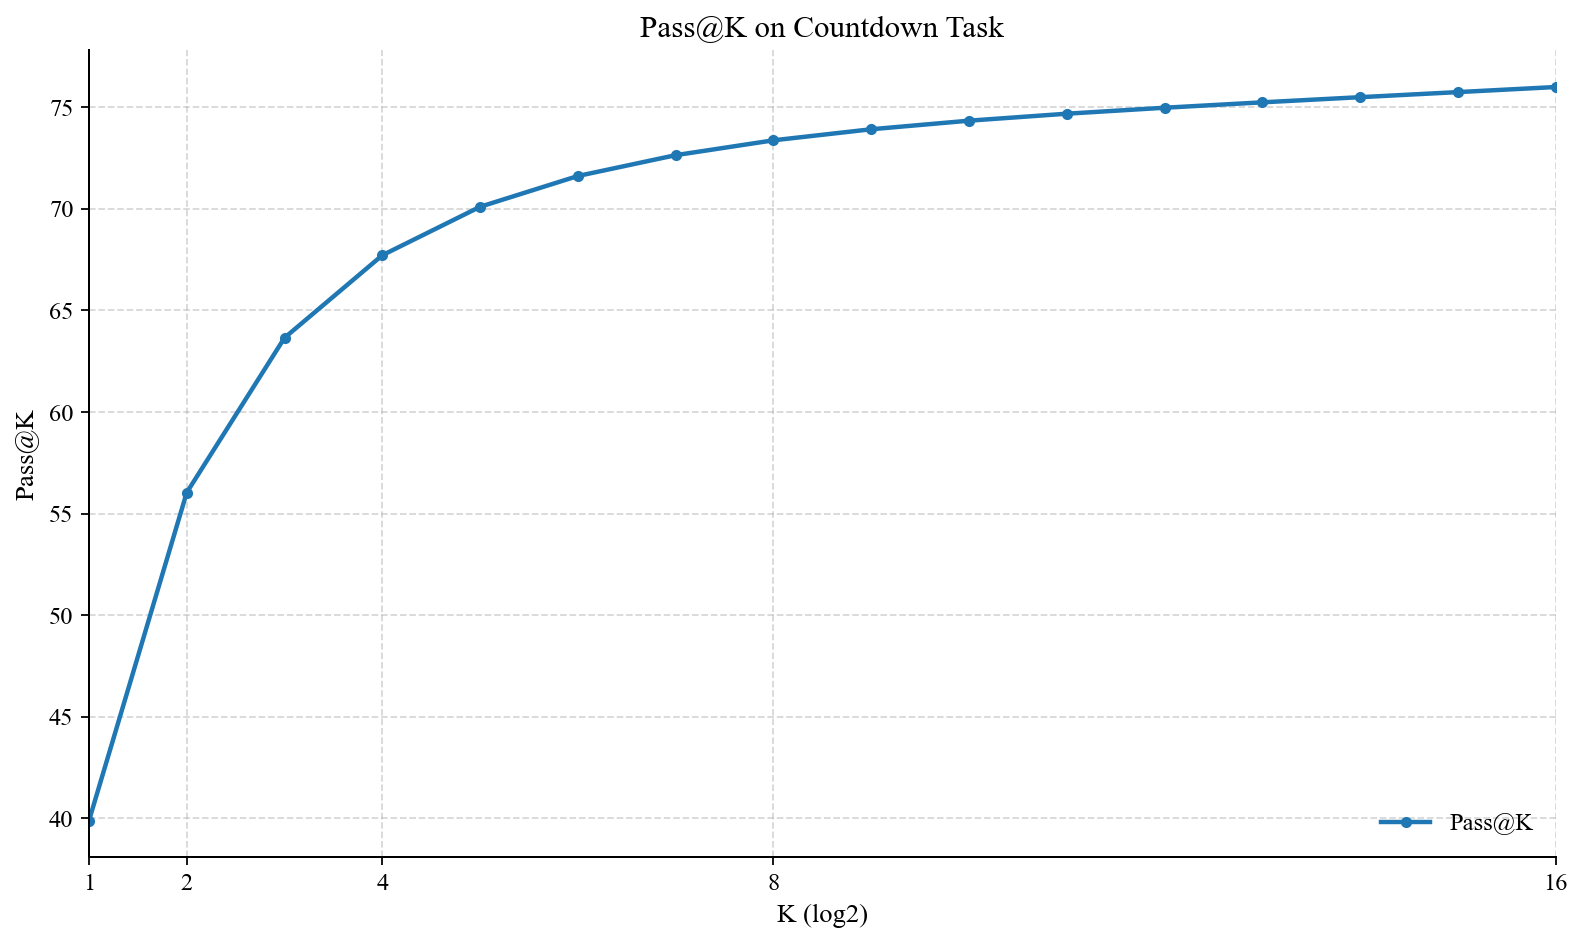

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FixedLocator, FuncFormatter

k = np.arange(1, len(pass_at_k_values) + 1)

# Create a figure for the plot
fig, ax = plt.subplots(figsize=(10, 6), dpi=160)

ax.plot(k, pass_at_k_values * 100, marker="o", markersize=4, linewidth=2, label="Pass@K")

ax.set_xlabel("K (log2)")
ax.set_ylabel("Pass@K")
ax.set_title("Pass@K on Countdown Task")
ax.set_xlim(1, k[-1])

major_ticks = [t for t in [1, 2, 4, 8, 16] if t <= k[-1]]
ax.xaxis.set_major_locator(FixedLocator(major_ticks))
ax.set_xticklabels([str(t) for t in major_ticks])

ax.grid(True, which="major", linestyle="--", linewidth=0.8, alpha=0.5)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.legend(frameon=False, loc="lower right")
plt.tight_layout()
plt.show()

Generating train split: 0 examples [00:00, ? examples/s]

Map (num_proc=16):   0%|          | 0/50 [00:00<?, ? examples/s]

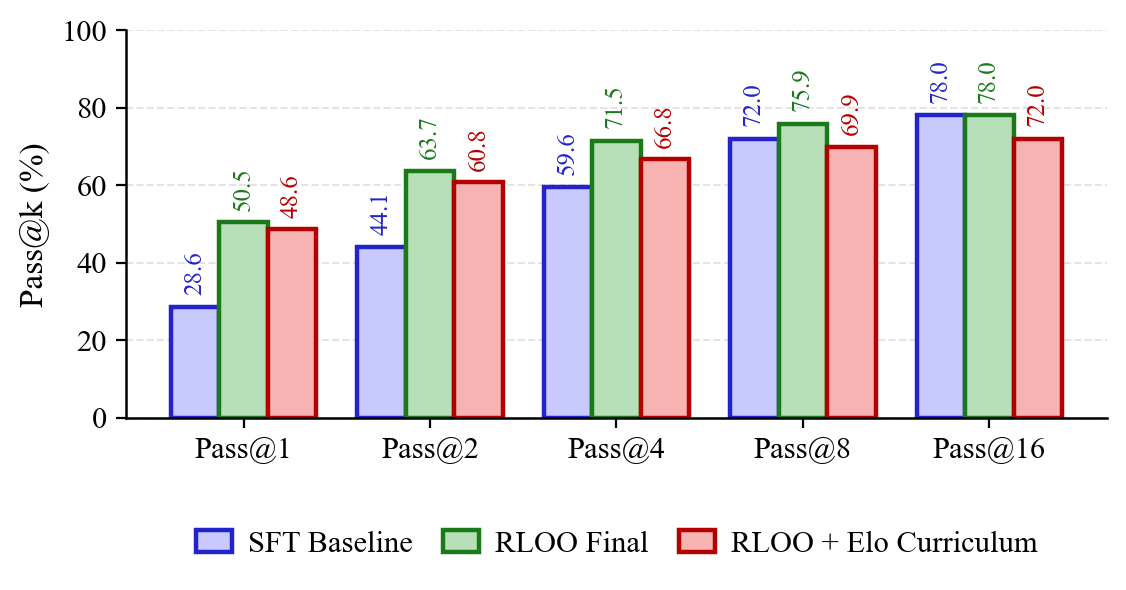

In [17]:
import os
import numpy as np
import datasets
import matplotlib as mpl
import matplotlib.pyplot as plt

#Conference paper font:
mpl.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "STIXGeneral", "DejaVu Serif"],
    "mathtext.fontset": "stix",
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 11,
    "axes.linewidth": 0.9,
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,
    "figure.dpi": 200,
    "savefig.dpi": 300,
})

ds_sft = datasets.Dataset.from_json("sft_baseline.json")
ds_rloo = datasets.Dataset.from_json("rloo_final.json")
ds_elo = datasets.Dataset.from_json("elo_eval.json")

ds_sft = ds_sft.map(map_fn, num_proc=os.cpu_count())
ds_rloo = ds_rloo.map(map_fn, num_proc=os.cpu_count())
ds_elo = ds_elo.map(map_fn, num_proc=os.cpu_count())

correct_sft = np.array(ds_sft["is_correct"])
correct_rloo = np.array(ds_rloo["is_correct"])
correct_elo = np.array(ds_elo["is_correct"])

pass_sft = np.asarray(calculate_pass_at_k_corrected(correct_sft)) * 100.0
pass_rloo = np.asarray(calculate_pass_at_k_corrected(correct_rloo)) * 100.0
pass_elo = np.asarray(calculate_pass_at_k_corrected(correct_elo)) * 100.0

ks = [1, 2, 4, 8, 16]
max_k = min(len(pass_sft), len(pass_rloo), len(pass_elo))
ks = [kk for kk in ks if kk <= max_k]
labels = [f"Pass@{kk}" for kk in ks]

sft_vals = np.array([pass_sft[kk - 1] for kk in ks])
rloo_vals = np.array([pass_rloo[kk - 1] for kk in ks])
elo_vals = np.array([pass_elo[kk - 1] for kk in ks])

fig, ax = plt.subplots(figsize=(5.6, 3.0))
x = np.arange(len(ks))
width = 0.26

sft_fill, sft_edge = "#c7c9ff", "#2323cc"
rloo_fill, rloo_edge = "#b8e0b8", "#1a7a1a"
elo_fill, elo_edge = "#f7b2b2", "#b30000"
def add_bar_labels(bars, color):
    for b in bars:
        h = b.get_height()
        ax.text(b.get_x() + b.get_width() / 2, h + 3.0, f"{h:.1f}", ha="center", va="bottom", rotation=90, rotation_mode="default", color=color, fontsize=9, clip_on=False)
sft_bars = ax.bar(
    x - width,
    sft_vals,
    width,
    label="SFT Baseline",
    color=sft_fill,
    edgecolor=sft_edge,
    linewidth=1.6,
)
rloo_bars = ax.bar(
    x,
    rloo_vals,
    width,
    label="RLOO Final",
    color=rloo_fill,
    edgecolor=rloo_edge,
    linewidth=1.6,
)
elo_bars = ax.bar(
    x + width,
    elo_vals,
    width,
    label="RLOO + Elo Curriculum",
    color=elo_fill,
    edgecolor=elo_edge,
    linewidth=1.6,
)

add_bar_labels(sft_bars, sft_edge)
add_bar_labels(rloo_bars, rloo_edge)
add_bar_labels(elo_bars, elo_edge)

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel("Pass@k (%)")
ax.set_ylim(0, 100)

ax.yaxis.grid(True, linestyle="--", linewidth=0.7, alpha=0.35)
ax.set_axisbelow(True)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.legend(frameon=False, loc="upper center", bbox_to_anchor=(0.5, -0.22), ncol=3, handlelength=1.2, handletextpad=0.5, columnspacing=1.0)

plt.tight_layout(pad=0.6)
plt.show()